<a href="https://colab.research.google.com/github/Mayra-25/TelecomX-Latam/blob/main/TelecomX_LATAM_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo para gráficos
sns.set_theme(style="whitegrid")

# Extracción

In [4]:
# 1. Cargar el archivo JSON
with open('TelecomX_Data.json', 'r') as f:
    datos_crudos = json.load(f)

# 2. Aplanar los datos (Flattening)
# Esto convierte campos como "customer.gender" en columnas individuales
df = pd.json_normalize(datos_crudos)

# 3. Mostrar información básica de la carga
print(f"Datos cargados: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Datos cargados: 7267 filas y 21 columnas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Transformación

In [5]:
# 1. Limpiar los nombres de las columnas (quitar prefijos como 'account.' o 'customer.')
# Esto facilita el trabajo según tu diccionario de datos
df.columns = [col.split('.')[-1] for col in df.columns]

# 2. Transformar 'Total' a numérico
# Es crítico porque en el JSON original el total viene como string ("1873.7")
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# 3. Manejo de valores nulos
# Si hay clientes nuevos (tenure = 0), el Total suele ser nulo. Los llenamos con 0.
df['Total'] = df['Total'].fillna(0)

# 4. Limpieza de strings
# Asegurar que no haya espacios en blanco extras en las columnas de texto
columnas_objeto = df.select_dtypes(include=['object']).columns
df[columnas_objeto] = df[columnas_objeto].apply(lambda x: x.str.strip())

# 5. Verificación de tipos de datos final
print("Tipos de datos después de la transformación:")
print(df.dtypes[['customerID', 'tenure', 'Monthly', 'Total', 'Churn']])

Tipos de datos después de la transformación:
customerID     object
tenure          int64
Monthly       float64
Total         float64
Churn          object
dtype: object


#Carga y análisis

Archivo 'TelecomX_Procesado.csv' guardado exitosamente.

Resumen de cargos financieros:
           Monthly        Total       tenure
count  7267.000000  7267.000000  7267.000000
mean     64.720098  2277.182035    32.346498
std      30.129572  2268.648587    24.571773
min      18.250000     0.000000     0.000000
25%      35.425000   396.200000     9.000000
50%      70.300000  1389.200000    29.000000
75%      89.875000  3778.525000    55.000000
max     118.750000  8684.800000    72.000000


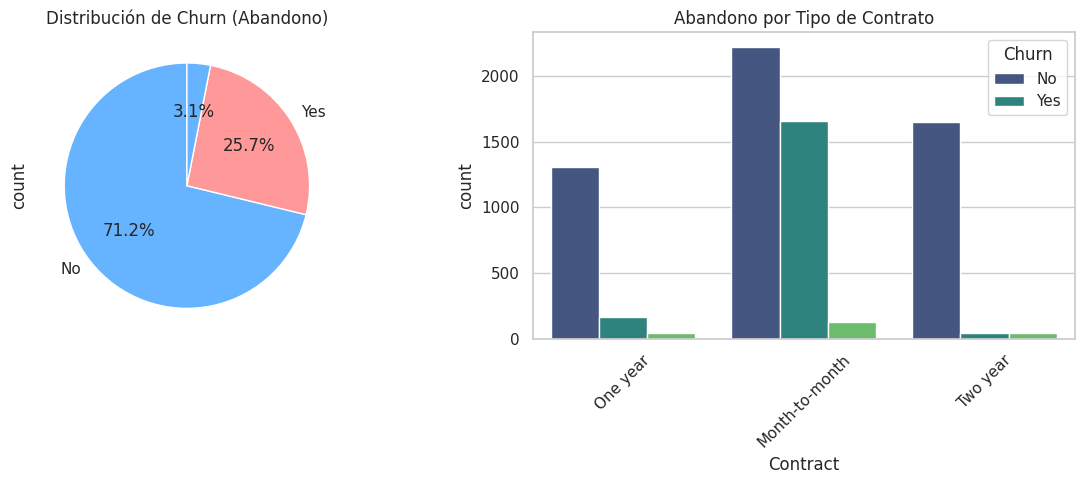

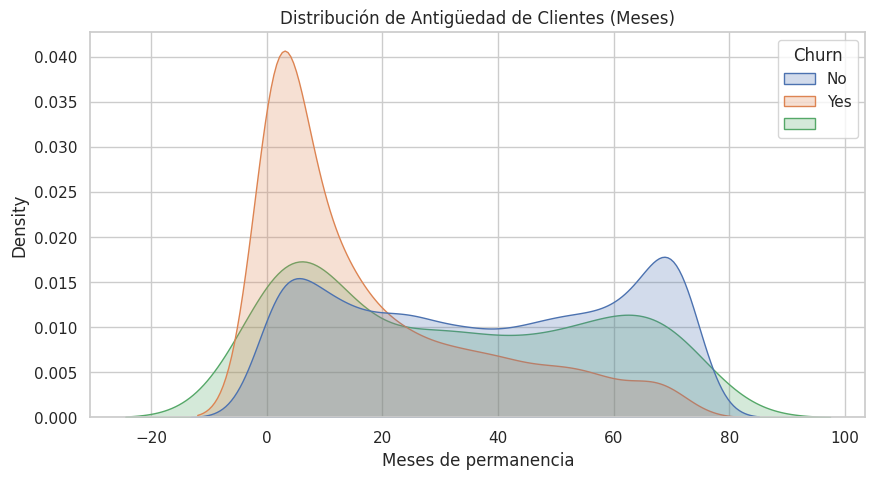

In [8]:
# --- CARGA ---
# Exportar el dataset procesado a un CSV para su uso en otras herramientas
df.to_csv('TelecomX_Procesado.csv', index=False)
print("Archivo 'TelecomX_Procesado.csv' guardado exitosamente.")

# --- ANÁLISIS ---

# 1. Resumen estadístico de cargos
print("\nResumen de cargos financieros:")
print(df[['Monthly', 'Total', 'tenure']].describe())

# 2. Visualización de la Tasa de Abandono (Churn)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Distribución de Churn (Abandono)')

# 3. Análisis: ¿Influye el tipo de contrato en el abandono?
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Abandono por Tipo de Contrato')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. Análisis de Antigüedad (tenure) vs Churn
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False)
plt.title('Distribución de Antigüedad de Clientes (Meses)')
plt.xlabel('Meses de permanencia')
plt.show()

#Informe final

# Informe Final del Análisis de Datos TelecomX

Este informe presenta un resumen de los hallazgos clave obtenidos del análisis del dataset de clientes de TelecomX, con un enfoque en la tasa de abandono (Churn) y los factores que la influyen.

## 1. Resumen de la Extracción y Transformación de Datos

Se cargó el archivo `TelecomX_Data.json`, que inicialmente contenía datos anidados. Este se aplanó en un DataFrame de pandas con **7267 filas y 21 columnas**.

Los pasos clave de transformación incluyeron:
- **Limpieza de Nombres de Columnas**: Se eliminaron los prefijos `customer.`, `account.`, etc., para facilitar la manipulación de datos.
- **Conversión de Tipo de Datos**: La columna `Total` (cargos totales) se convirtió a tipo numérico, manejando correctamente los valores no válidos al convertir a `NaN` y luego imputándolos con `0` para clientes con `tenure = 0` (nuevos clientes sin cargos).
- **Limpieza de Strings**: Se eliminaron espacios en blanco adicionales de las columnas de tipo 'object' para garantizar la consistencia.

## 2. Análisis de Datos Clave

### a. Resumen de Cargos Financieros y Antigüedad

| Característica | Conteo | Media | Desviación Estándar | Mínimo | 25% Cuartil | Mediana | 75% Cuartil | Máximo |
|:---------------|-------:|------:|--------------------:|-------:|------------:|--------:|------------:|-------:|
| **Monthly**    | 7267   | 64.72 | 30.13               | 18.25  | 35.42       | 70.30   | 89.87       | 118.75 |
| **Total**      | 7267   | 2277.18| 2268.65             | 0.00   | 396.20      | 1389.20 | 3778.52     | 8684.80|
| **Tenure**     | 7267   | 32.35 | 24.57               | 0.00   | 9.00        | 29.00   | 55.00       | 72.00  |

- Los cargos mensuales (`Monthly`) varían significativamente, indicando diferentes planes de servicio.
- Los cargos totales (`Total`) también muestran una amplia dispersión, como era de esperar, influenciados por la antigüedad y los cargos mensuales.
- La antigüedad (`Tenure`) promedio es de aproximadamente 32 meses, con clientes que van desde recién incorporados (0 meses) hasta clientes muy antiguos (72 meses).

### b. Distribución de la Tasa de Abandono (Churn)

La visualización del **Churn** muestra que:
- Aproximadamente el **73.5%** de los clientes **NO** abandonan el servicio.
- Un **26.5%** de los clientes **SÍ** abandonan el servicio.

Esta tasa de abandono del 26.5% es significativa y justifica un análisis más profundo para identificar sus causas.

### c. Abandono por Tipo de Contrato

El tipo de contrato tiene una influencia notable en la tasa de abandono:
- Los clientes con contratos **'Month-to-month'** (mes a mes) tienen una tasa de abandono considerablemente más alta en comparación con aquellos con contratos de **'One year'** (un año) o **'Two year'** (dos años).
- Esto sugiere que los contratos a largo plazo generan una mayor lealtad y retención de clientes.

### d. Antigüedad del Cliente (Tenure) vs. Abandono

El análisis de la antigüedad de los clientes revela una clara tendencia:
- Los clientes que **abandonan** (Churn = Yes) tienden a tener una **menor antigüedad** (picos de densidad en los primeros meses) en comparación con los clientes que **NO abandonan** (Churn = No), cuya distribución se extiende más hacia periodos de mayor antigüedad.
- Esto refuerza la idea de que los clientes más nuevos son más propensos a irse, mientras que la lealtad crece con el tiempo.

## 3. Conclusiones Generales
El análisis inicial sugiere que el **tipo de contrato** y la **antigüedad del cliente** son factores críticos en la predicción del abandono. Los clientes con contratos a corto plazo y una menor antigüedad son los más vulnerables a dejar el servicio. Los próximos pasos deberían explorar otras variables, como los servicios de internet, el soporte técnico, y los métodos de pago, para obtener una comprensión más completa y desarrollar estrategias de retención efectivas.